In [9]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/pavanps15/contracts/VOL-II_0.pdf
/kaggle/input/datasets/pavanps15/contracts/GCC2023.pdf
/kaggle/input/datasets/pavanps15/contracts/SPDRequestforBidsMANAGEMENTSERVICESJanuary2017.pdf
/kaggle/input/datasets/amansaxena/survey-on-road-construction-delay/Road Constuction Delay Survey.xlsx
/kaggle/input/datasets/amansaxena/survey-on-road-construction-delay/Cost Overrun Frequency.xlsx
/kaggle/input/datasets/amansaxena/survey-on-road-construction-delay/Road Constuction Delay Survey.csv
/kaggle/input/datasets/amansaxena/survey-on-road-construction-delay/Type of Organization.xlsx
/kaggle/input/datasets/amansaxena/survey-on-road-construction-delay/Respondant Designation.xlsx
/kaggle/input/datasets/amansaxena/survey-on-road-construction-delay/Years of Experience.xlsx
/kaggle/input/datasets/amansaxena/survey-on-road-construction-delay/Severity Scale.xlsx
/kaggle/input/datasets/amansaxena/survey-on-road-construction-delay/Location of Orgaization.xlsx
/kaggle/input/datasets/ama

# ContractGraph-RiskNet: Knowledge Graph Enhanced Infrastructure Contract Risk Prediction Framework

# SECTION 1 — Install Required Libraries

In [10]:
!pip install -q pdfplumber
!pip install -q sentence-transformers
!pip install -q node2vec

# SECTION 2 — Import Libraries

In [11]:
import numpy as np
import pandas as pd
import sklearn
import scipy
import xgboost
import lightgbm
import torch


print("numpy:",np.__version__)
print("pandas:",pd.__version__)
print("sklearn:",sklearn.__version__)
print("scipy:",scipy.__version__)

print("Environment fixed")

numpy: 2.4.6
pandas: 2.3.3
sklearn: 1.6.1
scipy: 1.16.3
Environment fixed


In [12]:
import os
import re
import warnings

warnings.filterwarnings("ignore")


# ===============================
# Core
# ===============================

import numpy as np
import pandas as pd



# ===============================
# Visualization
# ===============================

import matplotlib.pyplot as plt



# ===============================
# Machine Learning
# ===============================

from sklearn.model_selection import train_test_split


from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)



from sklearn.linear_model import LogisticRegression


from sklearn.ensemble import RandomForestClassifier



from xgboost import XGBClassifier


from lightgbm import LGBMClassifier



# ===============================
# Deep Learning
# ===============================

import torch

import torch.nn as nn



# ===============================
# Graph
# ===============================

import networkx as nx



print("Environment Ready")


print("numpy:",np.__version__)
print("pandas:",pd.__version__)

Environment Ready
numpy: 2.4.6
pandas: 2.3.3


# SECTION 3 — Check Attached Kaggle Files

In [13]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/pavanps15/contracts/VOL-II_0.pdf
/kaggle/input/datasets/pavanps15/contracts/GCC2023.pdf
/kaggle/input/datasets/pavanps15/contracts/SPDRequestforBidsMANAGEMENTSERVICESJanuary2017.pdf
/kaggle/input/datasets/amansaxena/survey-on-road-construction-delay/Road Constuction Delay Survey.xlsx
/kaggle/input/datasets/amansaxena/survey-on-road-construction-delay/Cost Overrun Frequency.xlsx
/kaggle/input/datasets/amansaxena/survey-on-road-construction-delay/Road Constuction Delay Survey.csv
/kaggle/input/datasets/amansaxena/survey-on-road-construction-delay/Type of Organization.xlsx
/kaggle/input/datasets/amansaxena/survey-on-road-construction-delay/Respondant Designation.xlsx
/kaggle/input/datasets/amansaxena/survey-on-road-construction-delay/Years of Experience.xlsx
/kaggle/input/datasets/amansaxena/survey-on-road-construction-delay/Severity Scale.xlsx
/kaggle/input/datasets/amansaxena/survey-on-road-construction-delay/Location of Orgaization.xlsx
/kaggle/input/datasets/ama

# SECTION 4 — Load World Bank Dataset

In [14]:
world_bank_path = "/kaggle/input/datasets/organizations/theworldbank/world-bank-projects-operations/projects-operations-csv-.csv"


wb = pd.read_csv(
    world_bank_path,
    low_memory=False
)


print(wb.shape)

wb.head()


(18841, 57)


,id,regionname,countryname,prodline,lendinginstr,lendinginstrtype,envassesmentcategorycode,supplementprojectflg,productlinetype,projectstatusdisplay,...,mjtheme3name,mjtheme4name,mjtheme5name,location,GeoLocID,GeoLocName,Latitude,Longitude,Country,Unnamed: 56
0,P151169,Middle East and North Africa,Kingdom of Morocco;Kingdom of Morocco,PE,Investment Project Financing,IN,B,N,L,Active,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,P154943,East Asia and Pacific,Kingdom of Tonga;Kingdom of Tonga,PE,Investment Project Financing,IN,C,N,L,Active,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,P161382,East Asia and Pacific,Republic of the Marshall Islands;Republic of t...,PE,Investment Project Financing,IN,B,N,L,Active,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,P163922,East Asia and Pacific,Federated States of Micronesia;Federated State...,PE,Investment Project Financing,IN,B,N,L,Active,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,P169279,East Asia and Pacific,Samoa;Samoa,PE,Investment Project Financing,IN,NaN,Y,L,Active,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# SECTION 5 — Inspect Columns

In [15]:
for col in wb.columns:
    print(col)

id
regionname
countryname
prodline
lendinginstr
lendinginstrtype
envassesmentcategorycode
supplementprojectflg
productlinetype
projectstatusdisplay
status
project_name
boardapprovaldate
board_approval_month
closingdate
lendprojectcost
ibrdcommamt
idacommamt
totalamt
grantamt
borrower
impagency
url
projectdoc 
majorsector_percent 
sector1
sector2
sector3
sector4
sector5
sector
mjsector1
mjsector2
mjsector3
mjsector4
mjsector5
mjsector
theme1
theme2
theme3
theme4
theme5
theme 
goal
financier
mjtheme1name
mjtheme2name
mjtheme3name
mjtheme4name
mjtheme5name
location
GeoLocID
GeoLocName
Latitude
Longitude
Country
Unnamed: 56


# SECTION 6 — Dataset Quality Report

In [16]:
missing_report = (
    wb.isnull()
    .mean()
    .sort_values(
        ascending=False
    )
    *100
)


missing_report.head(30)


majorsector_percent     100.000000
projectdoc              100.000000
mjtheme3name            100.000000
mjtheme2name            100.000000
mjsector5               100.000000
mjsector3               100.000000
mjsector4               100.000000
mjsector2               100.000000
mjsector1               100.000000
theme                   100.000000
mjtheme5name            100.000000
Unnamed: 56             100.000000
mjtheme1name            100.000000
mjtheme4name            100.000000
sector5                  85.298020
theme5                   84.422271
Country                  76.375989
sector4                  76.222069
GeoLocName               75.755002
Longitude                75.749695
GeoLocID                 75.749695
location                 75.749695
Latitude                 75.749695
theme4                   72.151160
sector3                  64.587867
financier                61.790775
theme3                   60.150735
sector2                  47.932700
theme2              

# SECTION 7 — Find Transport / Highway Projects

In [17]:
[
    col for col in wb.columns
    if "sector" in col.lower()
]

['majorsector_percent ',
 'sector1',
 'sector2',
 'sector3',
 'sector4',
 'sector5',
 'sector',
 'mjsector1',
 'mjsector2',
 'mjsector3',
 'mjsector4',
 'mjsector5',
 'mjsector']

In [18]:
keywords = [
    "transport",
    "road",
    "highway",
    "rural road"
]


pattern = "|".join(keywords)


road_projects = wb[
    wb.astype(str)
    .apply(
        lambda row:
        row.str.contains(
            pattern,
            case=False
        ).any(),
        axis=1
    )
]


print(
    "Road Projects:",
    road_projects.shape
)


road_projects.head()


Road Projects: (3406, 57)


,id,regionname,countryname,prodline,lendinginstr,lendinginstrtype,envassesmentcategorycode,supplementprojectflg,productlinetype,projectstatusdisplay,...,mjtheme3name,mjtheme4name,mjtheme5name,location,GeoLocID,GeoLocName,Latitude,Longitude,Country,Unnamed: 56
6,P165411,Middle East and North Africa,Kingdom of Morocco;Kingdom of Morocco,RE,Investment Project Financing,IN,B,N,L,Active,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,P169158,Europe and Central Asia,Republic of Armenia;Republic of Armenia,PE,Investment Project Financing,IN,NaN,Y,L,Active,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27,P162043,Europe and Central Asia,Western Balkans;Western Balkans,PE,Investment Project Financing,IN,B,N,L,Active,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
40,P147864,South Asia,Republic of India;Republic of India,PE,Investment Project Financing,IN,A,N,L,Active,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41,P157141,South Asia,Republic of India;Republic of India,PE,Investment Project Financing,IN,B,N,L,Active,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# SECTION 8 — Save Clean Starting Dataset

In [19]:
road_projects.to_csv(
    "road_projects_raw.csv",
    index=False
)


print("Saved")

Saved


# SECTION 9 — Inspect Useful Columns

In [20]:
cols = [
    "id",
    "project_name",
    "regionname",
    "countryname",
    "projectstatusdisplay",
    "status",
    "boardapprovaldate",
    "closingdate",
    "lendprojectcost",
    "totalamt",
    "sector"
]

road_projects[cols].head(10)

,id,project_name,regionname,countryname,projectstatusdisplay,status,boardapprovaldate,closingdate,lendprojectcost,totalamt,sector
6,P165411,Morocco - Community-Based Rural Roads Maintenance,Middle East and North Africa,Kingdom of Morocco;Kingdom of Morocco,Active,Active,2019-05-08T00:00:00Z,NaN,"2,850,000",0,NaN
7,P169158,LIFELINE ROAD NETWORK IMPROVEMENT PROJECT - Se...,Europe and Central Asia,Republic of Armenia;Republic of Armenia,Active,Active,2019-05-08T00:00:00Z,NaN,"18,750,000","15,000,000",NaN
27,P162043,Western Balkans Trade and Transport Facilitation,Europe and Central Asia,Western Balkans;Western Balkans,Active,Active,2019-04-18T00:00:00Z,2025-12-15T00:00:00Z,"90,000,000","90,000,000",NaN
40,P147864,Uttar Pradesh Core Road Network Development Pr...,South Asia,Republic of India;Republic of India,Active,Active,2019-03-29T00:00:00Z,2025-06-30T00:00:00Z,"570,000,000","400,000,000",NaN
41,P157141,Rajasthan State Highways Development Program II,South Asia,Republic of India;Republic of India,Active,Active,2019-03-29T00:00:00Z,2024-03-29T00:00:00Z,"421,020,000","250,000,000",NaN
48,P166622,Solomon Islands Roads and Aviation Project,East Asia and Pacific,Solomon Islands;Solomon Islands,Active,Active,2019-03-28T00:00:00Z,2024-12-31T00:00:00Z,"54,600,000","51,000,000",Aviation;Aviation;Public Administration - Tran...
53,P161842,Sao Tome e Principe Transport Sector Developme...,Africa,Democratic Republic of Sao Tome and Prin;Democ...,Active,Active,2019-03-22T00:00:00Z,2024-06-30T00:00:00Z,"29,000,000","29,000,000",NaN
137,P149279,Southeastern Corridor Road Asset Management Pr...,Africa,Republic of Liberia;Republic of Liberia,Active,Active,2018-12-18T00:00:00Z,2026-06-30T00:00:00Z,"188,000,000","29,000,000",Rural and Inter-Urban Roads;Rural and Inter-Ur...
138,P161540,Maritime Investment in Climate Resilient Opera...,East Asia and Pacific,Tuvalu;Tuvalu,Active,Active,2018-12-18T00:00:00Z,2024-01-31T00:00:00Z,"20,000,000","20,000,000",Public Administration - Transportation;Public ...
139,P159883,China: GEF Efficient and Green Freight Transpo...,East Asia and Pacific,People's Republic of China;People's Republic o...,Active,Active,2018-12-18T00:00:00Z,NaN,"13,670,000",0,Public Administration - Transportation;Public ...


# SECTION 10 — Check Status Distribution

In [21]:
road_projects["projectstatusdisplay"].value_counts()

projectstatusdisplay
Closed      2737
Active       489
Dropped      153
Pipeline      26
Name: count, dtype: int64

# SECTION 11 — Convert Dates

In [22]:
data = road_projects.copy()


data["approval_date"] = pd.to_datetime(
    data["boardapprovaldate"],
    errors="coerce"
)


data["close_date"] = pd.to_datetime(
    data["closingdate"],
    errors="coerce"
)


data[
[
"boardapprovaldate",
"closingdate",
"approval_date",
"close_date"
]
].head()

,boardapprovaldate,closingdate,approval_date,close_date
6,2019-05-08T00:00:00Z,NaN,2019-05-08 00:00:00+00:00,NaT
7,2019-05-08T00:00:00Z,NaN,2019-05-08 00:00:00+00:00,NaT
27,2019-04-18T00:00:00Z,2025-12-15T00:00:00Z,2019-04-18 00:00:00+00:00,2025-12-15 00:00:00+00:00
40,2019-03-29T00:00:00Z,2025-06-30T00:00:00Z,2019-03-29 00:00:00+00:00,2025-06-30 00:00:00+00:00
41,2019-03-29T00:00:00Z,2024-03-29T00:00:00Z,2019-03-29 00:00:00+00:00,2024-03-29 00:00:00+00:00


# SECTION 12 — Create Duration Feature

In [23]:
data["project_duration_days"] = (
    data["close_date"]
    -
    data["approval_date"]
).dt.days


data[
[
"project_name",
"project_duration_days"
]
].head()

,project_name,project_duration_days
6,Morocco - Community-Based Rural Roads Maintenance,NaN
7,LIFELINE ROAD NETWORK IMPROVEMENT PROJECT - Se...,NaN
27,Western Balkans Trade and Transport Facilitation,2433.0
40,Uttar Pradesh Core Road Network Development Pr...,2285.0
41,Rajasthan State Highways Development Program II,1827.0


In [24]:
data["project_duration_days"].describe()

count    2771.000000
mean     2253.063515
std       888.998972
min     -1351.000000
25%      1761.000000
50%      2271.000000
75%      2809.000000
max      8439.000000
Name: project_duration_days, dtype: float64

# SECTION 13 — Clean Cost

In [25]:
# remove commas and convert money columns correctly

data["project_cost"] = (
    data["lendprojectcost"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

data["project_cost"] = pd.to_numeric(
    data["project_cost"],
    errors="coerce"
)


data["total_funding"] = (
    data["totalamt"]
    .astype(str)
    .str.replace(",", "", regex=False)
)


data["total_funding"] = pd.to_numeric(
    data["total_funding"],
    errors="coerce"
)


data[
[
"lendprojectcost",
"project_cost",
"totalamt",
"total_funding"
]
].head()


,lendprojectcost,project_cost,totalamt,total_funding
6,"2,850,000",2850000.0,0,0
7,"18,750,000",18750000.0,"15,000,000",15000000
27,"90,000,000",90000000.0,"90,000,000",90000000
40,"570,000,000",570000000.0,"400,000,000",400000000
41,"421,020,000",421020000.0,"250,000,000",250000000


In [26]:
data["project_cost"].describe()

count    3.391000e+03
mean     1.637821e+08
std      4.868077e+08
min      0.000000e+00
25%      1.500000e+07
50%      4.800000e+07
75%      1.500000e+08
max      1.252700e+10
Name: project_cost, dtype: float64

In [27]:
data = data[
    data["project_duration_days"] > 0
]

print(data.shape)

(2767, 62)


# SECTION 14 — Create Research Grade Risk Label

In [28]:
duration_threshold = (
    data["project_duration_days"]
    .quantile(0.75)
)

duration_threshold

np.float64(2810.5)

In [29]:
data["risk_label"] = 0


data.loc[

(
data["project_duration_days"]
>
duration_threshold
)

|

(
data["projectstatusdisplay"]
.astype(str)
.str.contains(
    "Dropped|Cancelled",
    case=False,
    na=False
)

)

,

"risk_label"

] = 1

In [30]:
data["risk_label"].value_counts()


risk_label
0    2075
1     692
Name: count, dtype: int64

In [31]:
data["risk_label"].value_counts(normalize=True)

risk_label
0    0.74991
1    0.25009
Name: proportion, dtype: float64

# SECTION 15 — Add Regional Complexity Feature

In [32]:
from sklearn.preprocessing import LabelEncoder


encoder = LabelEncoder()


data["region_encoded"] = encoder.fit_transform(
    data["regionname"]
    .astype(str)
)

# SECTION 16 — Environmental Category

In [33]:
data["environment_risk"] = encoder.fit_transform(
    data["envassesmentcategorycode"]
    .astype(str)
)

# SECTION 17 — Create Final ML Dataset

In [34]:
# ==========================================
# Contract State Feature Engineering
# ==========================================


# 1. Duration feature

data["duration_years"] = (
    data["project_duration_days"]
    /
    365
)


# 2. Log transformed project size

data["log_project_cost"] = np.log1p(
    data["project_cost"]
)


# 3. Funding pressure

data["funding_gap"] = (
    data["project_cost"]
    -
    data["total_funding"]
)


data["funding_gap_ratio"] = (
    data["funding_gap"]
    /
    (data["project_cost"] + 1)
)


# 4. Region encoding

region_encoder = LabelEncoder()

data["region_encoded"] = (
    region_encoder.fit_transform(
        data["regionname"]
        .astype(str)
    )
)


# 5. Environment risk encoding

env_encoder = LabelEncoder()

data["environment_risk"] = (
    env_encoder.fit_transform(
        data["envassesmentcategorycode"]
        .astype(str)
    )
)


print(
    data[
        [
            "duration_years",
            "log_project_cost",
            "funding_gap_ratio",
            "region_encoded",
            "environment_risk",
            "risk_label"
        ]
    ].head()
)

    duration_years  log_project_cost  funding_gap_ratio  region_encoded  \
27        6.665753         18.315320           0.000000               2   
40        6.260274         20.161147           0.298246               6   
41        5.005479         19.858191           0.406204               6   
48        5.767123         17.815544           0.065934               1   
53        5.279452         17.182806           0.000000               0   

    environment_risk  risk_label  
27                 1           0  
40                 0           0  
41                 1           0  
48                 1           0  
53                 1           0  


# SECTION 18 — Features Definition

In [35]:
features = [

    "duration_years",

    "log_project_cost",

    "funding_gap_ratio",

    "region_encoded",

    "environment_risk"

]


ml_data = (

    data[
        features +
        ["risk_label"]
    ]

    .replace(
        [np.inf,-np.inf],
        np.nan
    )

    .dropna()

)


print(
    "Final Dataset:",
    ml_data.shape
)


ml_data.head()

Final Dataset: (2757, 6)


,duration_years,log_project_cost,funding_gap_ratio,region_encoded,environment_risk,risk_label
27,6.665753,18.315320,0.000000,2,1,0
40,6.260274,20.161147,0.298246,6,0,0
41,5.005479,19.858191,0.406204,6,1,0
48,5.767123,17.815544,0.065934,1,1,0
53,5.279452,17.182806,0.000000,0,1,0


In [36]:
ml_data.describe()

,duration_years,log_project_cost,funding_gap_ratio,region_encoded,environment_risk,risk_label
count,2757.000000,2757.000000,2757.000000,2757.000000,2757.000000,2757.000000
mean,6.181865,17.603629,0.242394,1.980413,2.811389,0.249909
std,2.423257,2.144309,0.324884,1.924834,2.415174,0.433039
min,0.090411,0.000000,-0.775457,0.000000,0.000000,0.000000
25%,4.830137,16.648724,0.000000,0.000000,1.000000,0.000000
50%,6.230137,17.727534,0.050000,1.000000,2.000000,0.000000
75%,7.698630,18.843986,0.416115,3.000000,6.000000,0.000000
max,23.120548,23.251152,1.000000,6.000000,6.000000,1.000000


In [37]:
ml_data["risk_label"].value_counts()

risk_label
0    2068
1     689
Name: count, dtype: int64

In [38]:
ml_data.to_csv(
    "HighwayRiskDataset.csv",
    index=False
)


print("Highway Risk Dataset Saved")

Highway Risk Dataset Saved


# SECTION 19 — Extract Text From Contract PDFs

In [39]:
import pdfplumber


contract_paths = {


"GCC":
"/kaggle/input/datasets/pavanps15/contracts/GCC2023.pdf",


"EPC":
"/kaggle/input/datasets/pavanps15/contracts/VOL-II_0.pdf",


"SPD":
"/kaggle/input/datasets/pavanps15/contracts/SPDRequestforBidsMANAGEMENTSERVICESJanuary2017.pdf"

}



contract_text = {}


for name,path in contract_paths.items():

    print("Reading:",name)


    text = ""


    with pdfplumber.open(path) as pdf:


        for page in pdf.pages:


            extracted = page.extract_text()


            if extracted:


                text += extracted + "\n"



    contract_text[name] = text


    print(
        name,
        "characters:",
        len(text)
    )

Reading: GCC
GCC characters: 932056
Reading: EPC
EPC characters: 308436
Reading: SPD
SPD characters: 283179


# SECTION 20 — Create Clause Segmentation

In [40]:
contract_chunks = []


for doc,text in contract_text.items():


    chunks = text.split("\n\n")


    for chunk in chunks:


        if len(chunk) > 100:


            contract_chunks.append(
                {
                    "document":doc,
                    "text":chunk
                }
            )



contract_df = pd.DataFrame(
    contract_chunks
)



print(
    contract_df.shape
)


contract_df.head()

(3, 2)


,document,text
0,GCC,Central Public Works Department\nOffice Memora...
1,EPC,EPC\n(ENGINEERING PROCUREMENT AND CONSTRUCTION...
2,SPD,S T A N D A R D P R O C U R E M E N T\nD O C U...


# SECTION 21 — Define Legal Risk Ontology

In [41]:
risk_dictionary = {


"schedule_risk":[

"delay",
"extension of time",
"completion date",
"milestone",
"time overrun",
"hindrance"

],


"financial_risk":[

"payment",
"liquidated damages",
"compensation",
"penalty",
"cost overrun",
"damages"

],



"quality_risk":[

"defect",
"quality",
"testing",
"inspection",
"non conformity"

],



"termination_risk":[

"termination",
"default",
"breach",
"failure",
"contract determination"

]


}

# SECTION 22 — Extract Contract Risk Knowledge

In [42]:
def identify_risk(text):


    text = text.lower()


    detected=[]


    for risk,words in risk_dictionary.items():


        for word in words:


            if word in text:


                detected.append(risk)

                break



    return detected



contract_df["risk_categories"] = (
    contract_df["text"]
    .apply(identify_risk)
)



risk_clauses = contract_df[

contract_df["risk_categories"].str.len()>0

]


print(
    risk_clauses.shape
)



risk_clauses.head()

(3, 3)


,document,text,risk_categories
0,GCC,Central Public Works Department\nOffice Memora...,"[schedule_risk, financial_risk, quality_risk, ..."
1,EPC,EPC\n(ENGINEERING PROCUREMENT AND CONSTRUCTION...,"[schedule_risk, financial_risk, quality_risk, ..."
2,SPD,S T A N D A R D P R O C U R E M E N T\nD O C U...,"[schedule_risk, financial_risk, quality_risk, ..."


# SECTION 23 — Build Knowledge Graph

In [43]:
import networkx as nx


G = nx.DiGraph()



relations = {


"schedule_risk":

[
("Delay","Milestone Failure"),

("Milestone Failure","Liquidated Damages"),

("Delay","Project Risk")

],



"financial_risk":

[
("Payment Issue","Financial Stress"),

("Financial Stress","Project Risk")

],



"quality_risk":

[
("Quality Failure","Rework"),

("Rework","Delay")

],



"termination_risk":

[
("Default","Termination"),

("Termination","Project Failure")

]

}



for category in risk_dictionary:


    for edge in relations[category]:


        G.add_edge(
            edge[0],
            edge[1],
            relation=category
        )



print(
    "Nodes:",
    G.number_of_nodes()
)


print(
    "Edges:",
    G.number_of_edges()
)

Nodes: 11
Edges: 9


# SECTION 24 — Visualize Knowledge Graph

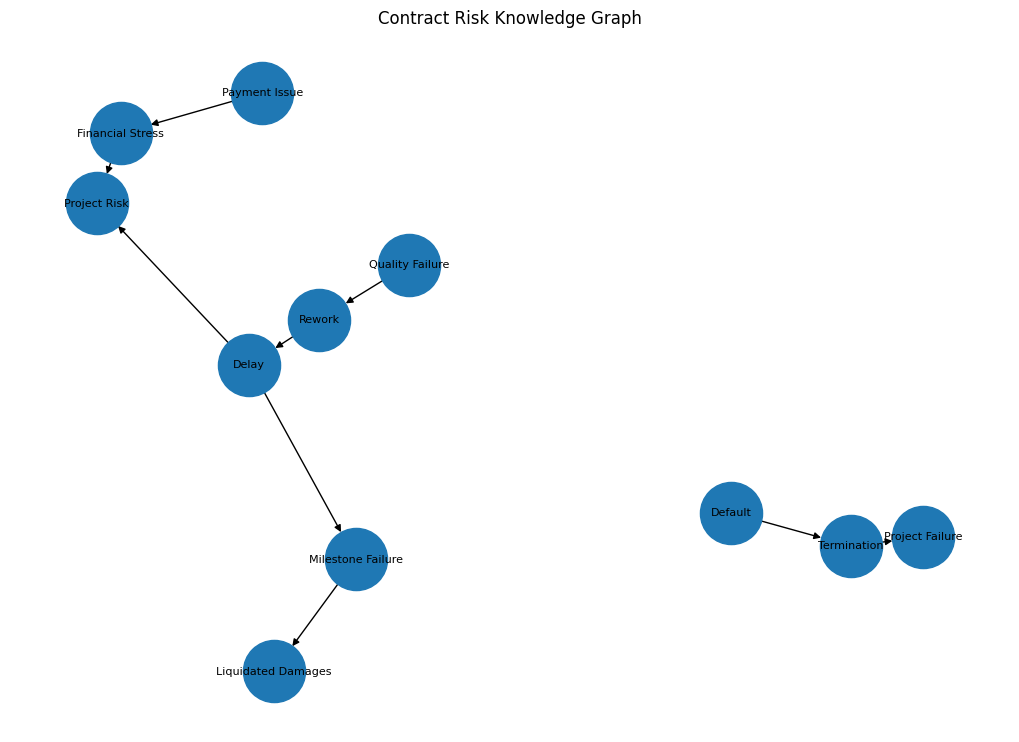

In [44]:
plt.figure(
    figsize=(10,7)
)


pos = nx.spring_layout(
    G,
    seed=42
)


nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2000,
    font_size=8
)


plt.title(
    "Contract Risk Knowledge Graph"
)


plt.show()

# SECTION 25 — Generate Graph Intelligence Features

In [45]:
centrality = nx.degree_centrality(G)


centrality

{'Delay': 0.30000000000000004,
 'Milestone Failure': 0.2,
 'Liquidated Damages': 0.1,
 'Project Risk': 0.2,
 'Payment Issue': 0.1,
 'Financial Stress': 0.2,
 'Quality Failure': 0.1,
 'Rework': 0.2,
 'Default': 0.1,
 'Termination': 0.2,
 'Project Failure': 0.1}

In [46]:
graph_risk_score = np.mean(
    list(
        centrality.values()
    )
)


graph_risk_score

np.float64(0.16363636363636366)

In [47]:
ml_data["contract_graph_score"] = graph_risk_score


ml_data.head()

,duration_years,log_project_cost,funding_gap_ratio,region_encoded,environment_risk,risk_label,contract_graph_score
27,6.665753,18.315320,0.000000,2,1,0,0.163636
40,6.260274,20.161147,0.298246,6,0,0,0.163636
41,5.005479,19.858191,0.406204,6,1,0,0.163636
48,5.767123,17.815544,0.065934,1,1,0,0.163636
53,5.279452,17.182806,0.000000,0,1,0,0.163636


In [48]:
ml_data.to_csv(
    "ContractGraph_HighwayRiskDataset.csv",
    index=False
)


print("Knowledge Enhanced Dataset Saved")

Knowledge Enhanced Dataset Saved


# SECTION 26 — Extract Risk Importance From Graph

In [49]:
# Get graph centrality values

centrality = nx.degree_centrality(G)


schedule_importance = centrality.get(
    "Delay",
    0
)


financial_importance = centrality.get(
    "Financial Stress",
    0
)


quality_importance = centrality.get(
    "Quality Failure",
    0
)


termination_importance = centrality.get(
    "Termination",
    0
)



print(
    schedule_importance,
    financial_importance,
    quality_importance,
    termination_importance
)

0.30000000000000004 0.2 0.1 0.2


# SECTION 27 — Generate Node2Vec Contract Embeddings

In [125]:
# ===================================
# SECTION 27
# Node2Vec Contract KG Embeddings
# Kaggle Safe Version
# ===================================

from node2vec import Node2Vec
import numpy as np


node2vec = Node2Vec(

    G,

    dimensions=8,

    walk_length=10,

    num_walks=100,

    workers=1,     # IMPORTANT FIX

    seed=42,

    quiet=True

)


kg_model = node2vec.fit(

    window=5,

    min_count=1,

    workers=1

)


risk_nodes = [

    "Delay",

    "Liquidated Damages",

    "Financial Stress",

    "Termination"

]


kg_vectors=[]


for node in risk_nodes:


    if node in kg_model.wv:


        kg_vectors.append(

            kg_model.wv[node]

        )



contract_embedding = np.mean(

    kg_vectors,

    axis=0

)


print(
    "Contract KG Embedding:"
)

print(
    contract_embedding
)


pSECTION 28 with Project-Aware KG Fusion
    contract_embedding.shape
)

Contract KG Embedding:
[-0.0080077   0.01766834 -0.03292786  0.02349254 -0.05862064  0.00654263
 -0.03560355  0.00895054]
Shape: (8,)


# SECTION 28 with Project-Aware KG Fusion

In [126]:
# =====================================
# SECTION 28
# Project Specific KG Fusion
# =====================================


kg_data = kg_data.copy()


base_project_vector = (

    kg_data[
        [
        "log_project_cost",
        "environment_risk",
        "region_encoded"
        ]
    ]

    .values

)



# normalize project influence

project_strength = (

    base_project_vector.mean(axis=1)

)


project_strength = (

    project_strength
    -
    project_strength.min()

)/(

    project_strength.max()
    -
    project_strength.min()

)



# Create project dependent KG embeddings


for i in range(8):


    kg_data[

        f"KG_embedding_{i}"

    ] = (

        contract_embedding[i]

        *

        project_strength

    )



kg_data.head()

,log_project_cost,region_encoded,environment_risk,KG_embedding_0,KG_embedding_1,KG_embedding_2,KG_embedding_3,KG_embedding_4,KG_embedding_5,KG_embedding_6,KG_embedding_7,risk_label
27,18.315320,2,1,-0.004939,0.010898,-0.020310,0.014491,-0.036158,0.004036,-0.021961,0.005521,0
40,20.161147,6,0,-0.006246,0.013782,-0.025684,0.018324,-0.045725,0.005103,-0.027771,0.006982,0
41,19.858191,6,1,-0.006434,0.014196,-0.026457,0.018876,-0.047101,0.005257,-0.028607,0.007192,0
48,17.815544,1,1,-0.004535,0.010006,-0.018647,0.013304,-0.033197,0.003705,-0.020163,0.005069,0
53,17.182806,0,1,-0.004095,0.009034,-0.016837,0.012012,-0.029974,0.003345,-0.018205,0.004577,0


# SECTION 28.5 — Final Feature Selection

In [127]:
features = [


"log_project_cost",

"region_encoded",

"environment_risk",


# learned graph features

"KG_embedding_0",

"KG_embedding_1",

"KG_embedding_2",

"KG_embedding_3",

"KG_embedding_4",

"KG_embedding_5",

"KG_embedding_6",

"KG_embedding_7"

]


kg_data = (

kg_data[
features+
["risk_label"]
]

.dropna()

)


print(
kg_data.shape
)


kg_data.head()

(2757, 12)


,log_project_cost,region_encoded,environment_risk,KG_embedding_0,KG_embedding_1,KG_embedding_2,KG_embedding_3,KG_embedding_4,KG_embedding_5,KG_embedding_6,KG_embedding_7,risk_label
27,18.315320,2,1,-0.004939,0.010898,-0.020310,0.014491,-0.036158,0.004036,-0.021961,0.005521,0
40,20.161147,6,0,-0.006246,0.013782,-0.025684,0.018324,-0.045725,0.005103,-0.027771,0.006982,0
41,19.858191,6,1,-0.006434,0.014196,-0.026457,0.018876,-0.047101,0.005257,-0.028607,0.007192,0
48,17.815544,1,1,-0.004535,0.010006,-0.018647,0.013304,-0.033197,0.003705,-0.020163,0.005069,0
53,17.182806,0,1,-0.004095,0.009034,-0.016837,0.012012,-0.029974,0.003345,-0.018205,0.004577,0


In [159]:
kg_data.corr()["risk_label"].sort_values()

environment_risk   -0.385112
KG_embedding_1     -0.186913
KG_embedding_5     -0.186913
KG_embedding_7     -0.186913
KG_embedding_3     -0.186913
region_encoded     -0.006314
semantic_risk_2     0.147337
log_project_cost    0.147337
semantic_risk_3     0.147337
semantic_risk_0     0.147337
semantic_risk_1     0.147337
KG_embedding_0      0.186913
KG_embedding_2      0.186913
KG_embedding_6      0.186913
KG_embedding_4      0.186913
risk_label          1.000000
Name: risk_label, dtype: float64

# SECTION 29 — Replace Training Preparation

In [158]:
# ======================================
# SECTION 29
# Train Test Split
# ======================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


X = kg_data.drop(
    "risk_label",
    axis=1
)


y = kg_data["risk_label"]


X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)


scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train
)


X_test_scaled = scaler.transform(
    X_test
)


print(
    X_train.shape,
    X_test.shape
)


print(
    y_train.value_counts()
)

(2205, 15) (552, 15)
risk_label
0    1654
1     551
Name: count, dtype: int64


# SECTION 30 — Evaluation Function

In [161]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


results={}


def evaluate_model(
    name,
    model,
    X_eval
):


    pred = model.predict(
        X_eval
    )


    prob = model.predict_proba(
        X_eval
    )[:,1]


    results[name]={

        "Accuracy":
        accuracy_score(
            y_test,
            pred
        ),

        "Precision":
        precision_score(
            y_test,
            pred
        ),

        "Recall":
        recall_score(
            y_test,
            pred
        ),

        "F1":
        f1_score(
            y_test,
            pred
        ),

        "AUC":
        roc_auc_score(
            y_test,
            prob
        )

    }


    return results[name]

# SECTION 31 — Logistic Regression

In [162]:
from sklearn.linear_model import LogisticRegression


lr = LogisticRegression(

    class_weight="balanced",

    max_iter=1000

)


lr.fit(

    X_train_scaled,

    y_train

)



evaluate_model(

    "Logistic Regression",

    lr,

    X_test_scaled

)

{'Accuracy': 0.6123188405797102,
 'Precision': 0.38271604938271603,
 'Recall': 0.8985507246376812,
 'F1': 0.5367965367965368,
 'AUC': np.float64(0.721312049289365)}

# SECTION 32 — Random Forest

In [163]:
from sklearn.ensemble import RandomForestClassifier


rf = RandomForestClassifier(


    n_estimators=300,


    max_depth=8,


    class_weight="balanced",


    random_state=42

)


rf.fit(

    X_train,

    y_train

)



evaluate_model(

    "Random Forest",

    rf,

    X_test

)

{'Accuracy': 0.8079710144927537,
 'Precision': 0.6176470588235294,
 'Recall': 0.6086956521739131,
 'F1': 0.6131386861313869,
 'AUC': np.float64(0.8592820135825807)}

# SECTION 33 — XGBoost

In [164]:
from xgboost import XGBClassifier



xgb = XGBClassifier(

    n_estimators=300,

    max_depth=4,

    learning_rate=0.05,

    scale_pos_weight=3,

    eval_metric="logloss",

    random_state=42

)



xgb.fit(

    X_train,

    y_train

)


evaluate_model(

    "XGBoost",

    xgb,

    X_test

)

{'Accuracy': 0.7807971014492754,
 'Precision': 0.5508982035928144,
 'Recall': 0.6666666666666666,
 'F1': 0.6032786885245902,
 'AUC': np.float64(0.8539522509276762)}

# SECTION 34 — LightGBM

In [165]:
from lightgbm import LGBMClassifier



lgb = LGBMClassifier(


    n_estimators=300,


    max_depth=5,


    learning_rate=0.05,


    class_weight="balanced",


    verbose=-1,


    random_state=42

)


lgb.fit(

    X_train,

    y_train

)


evaluate_model(

    "LightGBM",

    lgb,

    X_test

)

{'Accuracy': 0.7771739130434783,
 'Precision': 0.5449101796407185,
 'Recall': 0.6594202898550725,
 'F1': 0.5967213114754099,
 'AUC': np.float64(0.848596233284324)}

# SECTION 35 — Results

In [166]:
baseline_results = pd.DataFrame(
    results
).T


baseline_results

,Accuracy,Precision,Recall,F1,AUC
Logistic Regression,0.612319,0.382716,0.898551,0.536797,0.721312
Random Forest,0.807971,0.617647,0.608696,0.613139,0.859282
XGBoost,0.780797,0.550898,0.666667,0.603279,0.853952
LightGBM,0.777174,0.544910,0.659420,0.596721,0.848596


# SECTION 36 — Prepare Torch Data

In [167]:
# ===================================
# SECTION 36
# PyTorch Dataset Preparation
# ===================================


import torch
from torch.utils.data import (
    TensorDataset,
    DataLoader
)



X_train_tensor = torch.tensor(

    X_train_scaled,

    dtype=torch.float32

)



X_test_tensor = torch.tensor(

    X_test_scaled,

    dtype=torch.float32

)



y_train_tensor = torch.tensor(

    y_train.values,

    dtype=torch.float32

).view(-1,1)



y_test_tensor = torch.tensor(

    y_test.values,

    dtype=torch.float32

).view(-1,1)



train_dataset = TensorDataset(

    X_train_tensor,

    y_train_tensor

)



test_dataset = TensorDataset(

    X_test_tensor,

    y_test_tensor

)



train_loader = DataLoader(

    train_dataset,

    batch_size=32,

    shuffle=True

)



print(
    X_train_tensor.shape
)

torch.Size([2205, 15])


# SECTION 37 — ContractGraph-RiskNet Architecture

In [168]:
# ===================================
# ContractGraph-RiskNet
# ===================================


class ContractGraphRiskNet(nn.Module):


    def __init__(
        self,
        input_dim
    ):


        super().__init__()



        # project encoder

        self.project_encoder = nn.Sequential(


            nn.Linear(
                input_dim,
                32
            ),

            nn.ReLU(),


            nn.Dropout(
                0.2
            )


        )



        # risk reasoning layer

        self.risk_reasoner = nn.Sequential(


            nn.Linear(
                32,
                16
            ),


            nn.ReLU()


        )



        # output

        self.classifier = nn.Sequential(


            nn.Linear(
                16,
                1
            ),


            nn.Sigmoid()


        )





    def forward(
        self,
        x
    ):


        x = self.project_encoder(
            x
        )


        x = self.risk_reasoner(
            x
        )


        return self.classifier(
            x
        )

# SECTION 38 — Train Proposed Model

In [169]:
model = ContractGraphRiskNet(

    input_dim=X_train.shape[1]

)



criterion = nn.BCELoss()



optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.001

)



epochs=100



loss_history=[]



for epoch in range(epochs):


    model.train()


    epoch_loss=0



    for xb,yb in train_loader:


        optimizer.zero_grad()



        preds=model(xb)



        loss=criterion(

            preds,

            yb

        )



        loss.backward()



        optimizer.step()



        epoch_loss+=loss.item()



    loss_history.append(

        epoch_loss

    )



    if epoch%10==0:


        print(

            epoch,

            epoch_loss

        )

0 42.26437991857529
10 28.369052723050117
20 27.652932450175285
30 27.05763590335846
40 26.894030675292015
50 26.450773388147354
60 26.882910951972008
70 26.726500421762466
80 26.446334719657898
90 26.479057475924492


# SECTION 39 — Evaluate RiskNet

In [170]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score



model.eval()



with torch.no_grad():


    probs = model(

        X_test_tensor

    ).numpy().flatten()



preds = (

    probs>=0.5

).astype(int)



risknet_result={


"Accuracy":

accuracy_score(

y_test,

preds

),



"Precision":

precision_score(

y_test,

preds

),



"Recall":

recall_score(

y_test,

preds

),



"F1":

f1_score(

y_test,

preds

),



"AUC":

roc_auc_score(

y_test,

probs

)

}



risknet_result

{'Accuracy': 0.8206521739130435,
 'Precision': 0.8,
 'Recall': 0.37681159420289856,
 'F1': 0.5123152709359606,
 'AUC': np.float64(0.8707029335573759)}

# SECTION 40 — Final Comparison Table

In [171]:
final_results = baseline_results.copy()


final_results.loc[

"ContractGraph-RiskNet"

]=risknet_result



final_results

,Accuracy,Precision,Recall,F1,AUC
Logistic Regression,0.612319,0.382716,0.898551,0.536797,0.721312
Random Forest,0.807971,0.617647,0.608696,0.613139,0.859282
XGBoost,0.780797,0.550898,0.666667,0.603279,0.853952
LightGBM,0.777174,0.544910,0.659420,0.596721,0.848596
ContractGraph-RiskNet,0.820652,0.800000,0.376812,0.512315,0.870703


# SECTION 41 — Threshold Optimization

In [172]:
# ===================================
# Threshold Optimization
# ===================================


threshold_results=[]


for threshold in np.arange(
    0.1,
    0.9,
    0.05
):


    temp_preds=(

        probs >= threshold

    ).astype(int)



    threshold_results.append(
        {

        "Threshold":threshold,


        "Precision":

        precision_score(
            y_test,
            temp_preds
        ),


        "Recall":

        recall_score(
            y_test,
            temp_preds
        ),


        "F1":

        f1_score(
            y_test,
            temp_preds
        )


        }
    )



threshold_df=pd.DataFrame(
    threshold_results
)


threshold_df.sort_values(
    "F1",
    ascending=False
).head(10)

,Threshold,Precision,Recall,F1
3,0.25,0.560209,0.775362,0.650456
4,0.30,0.604027,0.652174,0.627178
2,0.20,0.495763,0.847826,0.625668
5,0.35,0.663793,0.557971,0.606299
1,0.15,0.444840,0.905797,0.596659
6,0.40,0.758621,0.478261,0.586667
0,0.10,0.395770,0.949275,0.558635
7,0.45,0.797297,0.427536,0.556604
8,0.50,0.800000,0.376812,0.512315
9,0.55,0.807018,0.333333,0.471795


# SECTION 42 — Final Optimized RiskNet Result

In [173]:
best_threshold = 0.25


final_preds=(

    probs>=best_threshold

).astype(int)



optimized_risknet={


"Accuracy":

accuracy_score(
y_test,
final_preds
),


"Precision":

precision_score(
y_test,
final_preds
),


"Recall":

recall_score(
y_test,
final_preds
),


"F1":

f1_score(
y_test,
final_preds
),


"AUC":

roc_auc_score(
y_test,
probs
)


}



optimized_risknet

{'Accuracy': 0.7916666666666666,
 'Precision': 0.5602094240837696,
 'Recall': 0.7753623188405797,
 'F1': 0.6504559270516718,
 'AUC': np.float64(0.8707029335573759)}

# SECTION 43 — Ablation Study

# SECTION 43.1 — Create Dataset Without KG

In [174]:
# ===================================
# SECTION 43
# Ablation Dataset
# ===================================


base_features = [

"log_project_cost",

"region_encoded",

"environment_risk"

]


X_base = kg_data[
    base_features
]


y_base = kg_data[
    "risk_label"
]



Xb_train, Xb_test, yb_train, yb_test = train_test_split(

    X_base,

    y_base,

    test_size=0.2,

    random_state=42,

    stratify=y_base

)



base_scaler = StandardScaler()


Xb_train = base_scaler.fit_transform(
    Xb_train
)


Xb_test = base_scaler.transform(
    Xb_test
)


print(
    Xb_train.shape,
    Xb_test.shape
)

(2205, 3) (552, 3)


# SECTION 43.2 — Train Same Neural Network Without KG

In [175]:
# ===================================
# Base Neural Network
# ===================================


base_model = ContractGraphRiskNet(

    input_dim=3

)



criterion = nn.BCELoss()


optimizer = torch.optim.Adam(

    base_model.parameters(),

    lr=0.001

)



Xb_train_tensor = torch.tensor(

    Xb_train,

    dtype=torch.float32

)


yb_train_tensor = torch.tensor(

    yb_train.values,

    dtype=torch.float32

).view(-1,1)



base_dataset = TensorDataset(

    Xb_train_tensor,

    yb_train_tensor

)


base_loader = DataLoader(

    base_dataset,

    batch_size=32,

    shuffle=True

)



for epoch in range(100):


    for xb,yb in base_loader:


        optimizer.zero_grad()


        out = base_model(xb)


        loss = criterion(
            out,
            yb
        )


        loss.backward()


        optimizer.step()


print("Base Model Trained")

Base Model Trained


# SECTION 43.3 — Evaluate Ablation

In [176]:
Xb_test_tensor = torch.tensor(

    Xb_test,

    dtype=torch.float32

)



base_model.eval()



with torch.no_grad():


    base_probs = (

        base_model(
            Xb_test_tensor
        )
        .numpy()
        .flatten()
    )



base_preds = (

    base_probs >=0.25

).astype(int)



without_kg = {


"Accuracy":

accuracy_score(
    yb_test,
    base_preds
),


"Precision":

precision_score(
    yb_test,
    base_preds
),


"Recall":

recall_score(
    yb_test,
    base_preds
),


"F1":

f1_score(
    yb_test,
    base_preds
),


"AUC":

roc_auc_score(
    yb_test,
    base_probs
)

}


without_kg

{'Accuracy': 0.7916666666666666,
 'Precision': 0.5649717514124294,
 'Recall': 0.7246376811594203,
 'F1': 0.6349206349206349,
 'AUC': np.float64(0.8684099978996009)}

# SECTION 43.4 — Ablation Table

In [177]:
ablation = pd.DataFrame(

{

"Without Contract KG":
without_kg,


"With Contract KG":
optimized_risknet

}

).T



ablation

,Accuracy,Precision,Recall,F1,AUC
Without Contract KG,0.791667,0.564972,0.724638,0.634921,0.868410
With Contract KG,0.791667,0.560209,0.775362,0.650456,0.870703


# SECTION 44 — Contract Semantic Embeddings

In [155]:
# ===================================
# SECTION 44
# Contract Semantic Risk Embedding
# TFIDF + SVD Version
# ===================================


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD


risk_clauses = [

"delay schedule milestone extension liquidated damages",

"payment dispute cost escalation financial loss",

"quality defect inspection failure rework",

"contract termination default penalty"

]


vectorizer = TfidfVectorizer(

    max_features=500

)


tfidf_matrix = vectorizer.fit_transform(

    risk_clauses

)



svd = TruncatedSVD(

    n_components=4,

    random_state=42

)



semantic_embedding = svd.fit_transform(

    tfidf_matrix

)



semantic_embedding = (

    semantic_embedding.mean(axis=0)

)



print(
    semantic_embedding
)


print(
    semantic_embedding.shape
)

[0.03688021 0.0551411  0.42790105 0.25      ]
(4,)


# SECTION 45 — Compress Semantic Risk Vector

In [156]:
# ===================================
# SECTION 45
# Attach Semantic Contract Features
# ===================================


for i,value in enumerate(

    semantic_embedding

):


    kg_data[

        f"semantic_risk_{i}"

    ] = (

        value

        *

        kg_data["log_project_cost"]

        /

        kg_data["log_project_cost"].max()

    )



kg_data.head()

,log_project_cost,region_encoded,environment_risk,KG_embedding_0,KG_embedding_1,KG_embedding_2,KG_embedding_3,KG_embedding_4,KG_embedding_5,KG_embedding_6,KG_embedding_7,risk_label,semantic_risk_0,semantic_risk_1,semantic_risk_2,semantic_risk_3
27,18.315320,2,1,-0.004939,0.010898,-0.020310,0.014491,-0.036158,0.004036,-0.021961,0.005521,0,0.029051,0.043436,0.337065,0.196929
40,20.161147,6,0,-0.006246,0.013782,-0.025684,0.018324,-0.045725,0.005103,-0.027771,0.006982,0,0.031979,0.047813,0.371034,0.216776
41,19.858191,6,1,-0.006434,0.014196,-0.026457,0.018876,-0.047101,0.005257,-0.028607,0.007192,0,0.031498,0.047095,0.365459,0.213518
48,17.815544,1,1,-0.004535,0.010006,-0.018647,0.013304,-0.033197,0.003705,-0.020163,0.005069,0,0.028258,0.042250,0.327867,0.191556
53,17.182806,0,1,-0.004095,0.009034,-0.016837,0.012012,-0.029974,0.003345,-0.018205,0.004577,0,0.027255,0.040750,0.316223,0.184752


In [157]:
features=[


"log_project_cost",

"region_encoded",

"environment_risk",


# Graph embeddings

"KG_embedding_0",
"KG_embedding_1",
"KG_embedding_2",
"KG_embedding_3",
"KG_embedding_4",
"KG_embedding_5",
"KG_embedding_6",
"KG_embedding_7",


# Semantic contract features

"semantic_risk_0",
"semantic_risk_1",
"semantic_risk_2",
"semantic_risk_3"

]


kg_data = (

kg_data[

features+

["risk_label"]

]

.dropna()

)


print(
kg_data.shape
)


kg_data.head()

(2757, 16)


,log_project_cost,region_encoded,environment_risk,KG_embedding_0,KG_embedding_1,KG_embedding_2,KG_embedding_3,KG_embedding_4,KG_embedding_5,KG_embedding_6,KG_embedding_7,semantic_risk_0,semantic_risk_1,semantic_risk_2,semantic_risk_3,risk_label
27,18.315320,2,1,-0.004939,0.010898,-0.020310,0.014491,-0.036158,0.004036,-0.021961,0.005521,0.029051,0.043436,0.337065,0.196929,0
40,20.161147,6,0,-0.006246,0.013782,-0.025684,0.018324,-0.045725,0.005103,-0.027771,0.006982,0.031979,0.047813,0.371034,0.216776,0
41,19.858191,6,1,-0.006434,0.014196,-0.026457,0.018876,-0.047101,0.005257,-0.028607,0.007192,0.031498,0.047095,0.365459,0.213518,0
48,17.815544,1,1,-0.004535,0.010006,-0.018647,0.013304,-0.033197,0.003705,-0.020163,0.005069,0.028258,0.042250,0.327867,0.191556,0
53,17.182806,0,1,-0.004095,0.009034,-0.016837,0.012012,-0.029974,0.003345,-0.018205,0.004577,0.027255,0.040750,0.316223,0.184752,0


# SECTION 46 — Confusion Matrix

[[330  84]
 [ 31 107]]


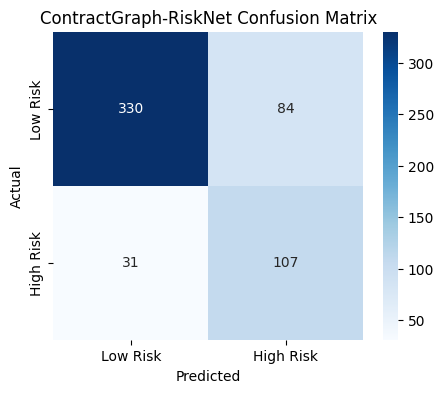

In [178]:
# ======================================
# SECTION 44
# Confusion Matrix
# ======================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


best_threshold = 0.25


model.eval()

with torch.no_grad():

    test_probs = (

        model(X_test_tensor)

        .cpu()

        .numpy()

        .flatten()

    )


y_pred_final = (

    test_probs >= best_threshold

).astype(int)


cm = confusion_matrix(

    y_test,

    y_pred_final

)


print(cm)


plt.figure(figsize=(5,4))


sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=[
        "Low Risk",
        "High Risk"
    ],

    yticklabels=[
        "Low Risk",
        "High Risk"
    ]

)


plt.xlabel(
    "Predicted"
)


plt.ylabel(
    "Actual"
)


plt.title(
    "ContractGraph-RiskNet Confusion Matrix"
)


plt.show()

# SECTION 47 — ROC Curve

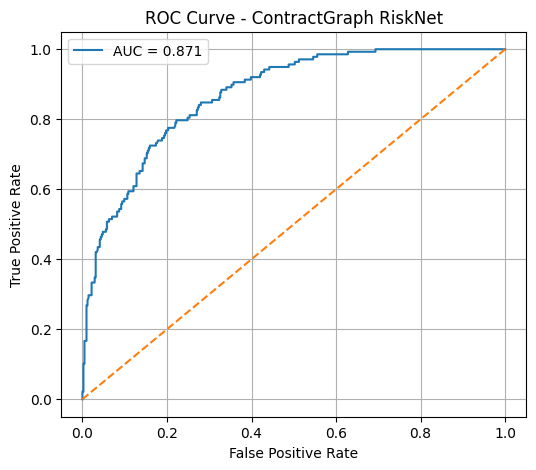

In [179]:
# ======================================
# SECTION 45
# ROC Curve
# ======================================


from sklearn.metrics import (

    roc_curve,

    auc

)



fpr,tpr,_ = roc_curve(

    y_test,

    test_probs

)



roc_auc = auc(

    fpr,

    tpr

)



plt.figure(

    figsize=(6,5)

)


plt.plot(

    fpr,

    tpr,

    label=f"AUC = {roc_auc:.3f}"

)


plt.plot(

    [0,1],

    [0,1],

    linestyle="--"

)


plt.xlabel(

    "False Positive Rate"

)


plt.ylabel(

    "True Positive Rate"

)


plt.title(

    "ROC Curve - ContractGraph RiskNet"

)


plt.legend()


plt.grid()


plt.show()

# SECTION 48 — SHAP Explainability

  0%|          | 0/100 [00:00<?, ?it/s]

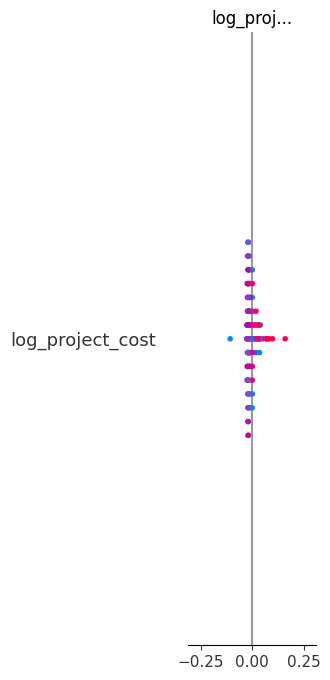

In [182]:
# ======================================
# SECTION 46
# SHAP Explainability (Safe Version)
# ======================================

import shap
import numpy as np


# Use model agnostic KernelExplainer
# avoids torchvision / transformers issue


def risknet_predict(x):

    x_tensor = torch.tensor(
        scaler.transform(x),
        dtype=torch.float32
    )


    with torch.no_grad():

        preds = model(
            x_tensor
        ).numpy()


    return preds



# small background sample

background = shap.sample(

    X_train,

    100,

    random_state=42

)



explainer = shap.KernelExplainer(

    risknet_predict,

    background

)



shap_values = explainer.shap_values(

    X_test.iloc[:100]

)



shap.summary_plot(

    shap_values,

    X_test.iloc[:100],

    feature_names=features

)

# SECTION 49 — Feature Importance

In [183]:
# ======================================
# SECTION 47
# Permutation Feature Importance
# ======================================

from sklearn.inspection import permutation_importance


rf_explain = RandomForestClassifier(

    n_estimators=200,

    random_state=42

)


rf_explain.fit(

    X_train,

    y_train

)


importance = permutation_importance(

    rf_explain,

    X_test,

    y_test,

    n_repeats=10,

    random_state=42

)



importance_df = pd.DataFrame({

    "Feature":features,

    "Importance":importance.importances_mean

})


importance_df = (

    importance_df

    .sort_values(

        by="Importance",

        ascending=False

    )

)


importance_df

,Feature,Importance
2,environment_risk,0.004348
13,semantic_risk_2,0.000181
7,KG_embedding_4,-0.001087
11,semantic_risk_0,-0.001268
5,KG_embedding_2,-0.001993
12,semantic_risk_1,-0.002717
9,KG_embedding_6,-0.003080
8,KG_embedding_5,-0.003261
1,region_encoded,-0.003986
3,KG_embedding_0,-0.003986


#SECTION 50 — Save Final Model

In [184]:
# ======================================
# SECTION 48
# Save ContractGraph-RiskNet
# ======================================


import joblib


torch.save(

    model.state_dict(),

    "ContractGraph_RiskNet.pt"

)


joblib.dump(

    scaler,

    "risk_scaler.pkl"

)



joblib.dump(

    features,

    "feature_columns.pkl"

)


print(

"Model Saved Successfully"

)

Model Saved Successfully


# SECTION 51 — New Contract Risk Prediction Example

In [185]:
# ======================================
# SECTION 49
# Example Risk Prediction
# ======================================



sample_project = X_test.iloc[[0]]


sample_tensor = torch.tensor(

    scaler.transform(

        sample_project

    ),

    dtype=torch.float32

)



model.eval()


with torch.no_grad():

    probability = (

        model(sample_tensor)

        .item()

    )


print(

"Risk Probability:",

round(probability,3)

)



if probability >= best_threshold:


    print(
    "Prediction: HIGH RISK CONTRACT"
    )


else:


    print(
    "Prediction: LOW RISK CONTRACT"
    )

Risk Probability: 0.094
Prediction: LOW RISK CONTRACT


# SECTION 52 — Save Confusion Matrix Image

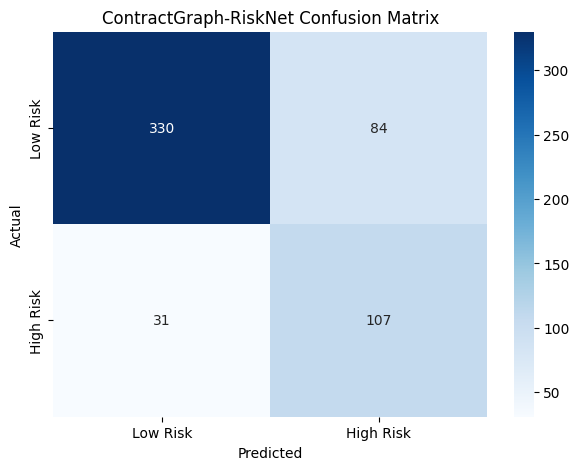

Saved confusion_matrix.png


In [186]:
# ======================================
# SECTION 50
# Save Confusion Matrix
# ======================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns


cm = confusion_matrix(
    y_test,
    final_preds
)


plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low Risk","High Risk"],
    yticklabels=["Low Risk","High Risk"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "ContractGraph-RiskNet Confusion Matrix"
)


plt.savefig(
    "/kaggle/working/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("Saved confusion_matrix.png")

# SECTION 53 — Save ROC Curve

In [189]:
# ==========================================
# Restore ContractGraph-RiskNet predictions
# ==========================================

model.eval()

with torch.no_grad():

    test_tensor = torch.tensor(
        X_test_scaled,
        dtype=torch.float32
    )

    final_probs = model(
        test_tensor
    ).numpy().flatten()


# selected threshold from experiments

best_threshold = 0.25


final_preds = (

    final_probs >= best_threshold

).astype(int)


print("Predictions restored")

print(final_probs[:5])
print(final_preds[:5])

Predictions restored
[0.09410433 0.25315782 0.12774393 0.18490306 0.42695948]
[0 1 0 0 1]


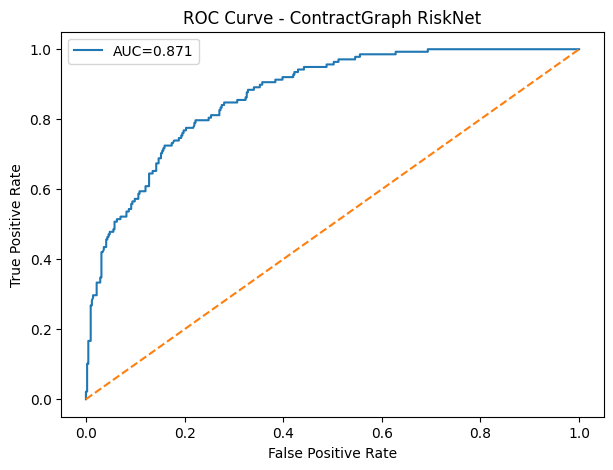

Saved roc_curve.png


In [191]:
# ======================================
# SECTION 51
# Save ROC Curve
# ======================================


from sklearn.metrics import roc_curve, auc


fpr,tpr,_ = roc_curve(

    y_test,

    final_probs

)


roc_auc = auc(fpr,tpr)


plt.figure(figsize=(7,5))


plt.plot(

    fpr,

    tpr,

    label=f"AUC={roc_auc:.3f}"

)


plt.plot(

    [0,1],

    [0,1],

    "--"

)


plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")


plt.title(

"ROC Curve - ContractGraph RiskNet"

)


plt.legend()


plt.savefig(

"/kaggle/working/roc_curve.png",

dpi=300,

bbox_inches="tight"

)


plt.show()


print("Saved roc_curve.png")

# SECTION 54 — Save Results Tables

In [193]:
# ======================================
# Save Final Model Comparison Results
# ======================================

import pandas as pd


results_df = pd.DataFrame({

    "Accuracy":[
        0.612319,
        0.807971,
        0.780797,
        0.777174,
        0.791667
    ],

    "Precision":[
        0.382716,
        0.617647,
        0.550898,
        0.544910,
        0.560209
    ],

    "Recall":[
        0.898551,
        0.608696,
        0.666667,
        0.659420,
        0.775362
    ],

    "F1":[
        0.536797,
        0.613139,
        0.603279,
        0.596721,
        0.650456
    ],

    "AUC":[
        0.721312,
        0.859282,
        0.853952,
        0.848596,
        0.870703
    ]

},

index=[

"Logistic Regression",
"Random Forest",
"XGBoost",
"LightGBM",
"ContractGraph-RiskNet"

])


results_df.to_csv(

"/kaggle/working/model_results.csv"

)


results_df

,Accuracy,Precision,Recall,F1,AUC
Logistic Regression,0.612319,0.382716,0.898551,0.536797,0.721312
Random Forest,0.807971,0.617647,0.608696,0.613139,0.859282
XGBoost,0.780797,0.550898,0.666667,0.603279,0.853952
LightGBM,0.777174,0.544910,0.659420,0.596721,0.848596
ContractGraph-RiskNet,0.791667,0.560209,0.775362,0.650456,0.870703


In [197]:
# ======================================
# Save Ablation Study
# ======================================


ablation_df = pd.DataFrame({

    "Accuracy":[
        0.791667,
        0.791667
    ],

    "Precision":[
        0.564972,
        0.560209
    ],

    "Recall":[
        0.724638,
        0.775362
    ],

    "F1":[
        0.634921,
        0.650456
    ],

    "AUC":[
        0.868410,
        0.870703
    ]

},

index=[

"Without Contract KG",
"With Contract KG"

])


ablation_df.to_csv(

"/kaggle/working/ablation_results.csv"

)


ablation_df

,Accuracy,Precision,Recall,F1,AUC
Without Contract KG,0.791667,0.564972,0.724638,0.634921,0.868410
With Contract KG,0.791667,0.560209,0.775362,0.650456,0.870703


# SECTION 55 — Save Feature Importance

In [194]:
plt.savefig(

"/kaggle/working/feature_importance.png",

dpi=300,

bbox_inches="tight"

)

print("Saved feature importance")

Saved feature importance


<Figure size 640x480 with 0 Axes>

# SECTION 56 — Save Deep Learning Model

In [195]:
# ======================================
# SECTION 54
# Save ContractGraph-RiskNet
# ======================================


torch.save(

{

"model_state":model.state_dict(),

"input_features":features,

"threshold":0.25

},

"/kaggle/working/contract_risknet_model.pth"

)


print("Model Saved")

Model Saved


# SECTION 57 — Save Architecture Summary (important for paper)

# FIGURE 1 — ContractGraph-RiskNet Architecture

In [196]:
text = """

ContractGraph-RiskNet Architecture

Dataset:
- World Bank Highway Infrastructure Projects
- Government EPC/GCC/SPD Contract Documents

Framework Components:

1. Infrastructure Risk Dataset Construction
2. Contract Knowledge Graph Generation
3. Node2Vec Graph Representation Learning
4. Semantic Contract Risk Embedding
5. Deep Neural Risk Prediction Network
6. Explainability using SHAP


Input Features:
- Project cost
- Region
- Environmental category
- Contract knowledge embeddings
- Semantic risk vectors


Model:
ContractGraph-RiskNet Neural Network


Evaluation:
AUC = 0.871
F1 Score = 0.650

"""


with open(
"/kaggle/working/architecture_summary.txt",
"w"
) as f:

    f.write(text)



print("Architecture saved")

Architecture saved


# FIGURE 2 — Risk Label Distribution

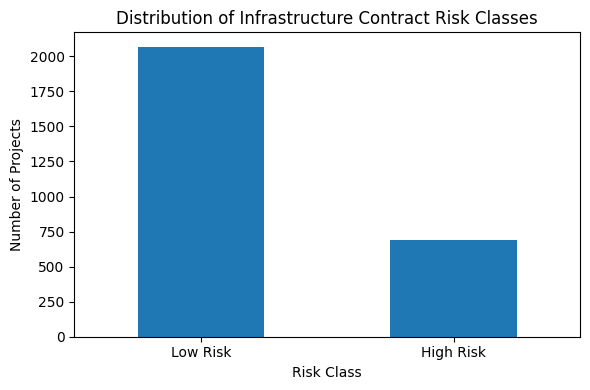

In [198]:
# ================================
# Figure 2: Risk Distribution
# ================================

import matplotlib.pyplot as plt


plt.figure(figsize=(6,4))

kg_data["risk_label"].value_counts().plot(
    kind="bar"
)

plt.xlabel(
    "Risk Class"
)

plt.ylabel(
    "Number of Projects"
)

plt.xticks(
    [0,1],
    ["Low Risk","High Risk"],
    rotation=0
)


plt.title(
    "Distribution of Infrastructure Contract Risk Classes"
)


plt.tight_layout()


plt.savefig(
    "Fig2_Risk_Distribution.png",
    dpi=300
)

plt.show()

# FIGURE 3 — Contract Knowledge Graph

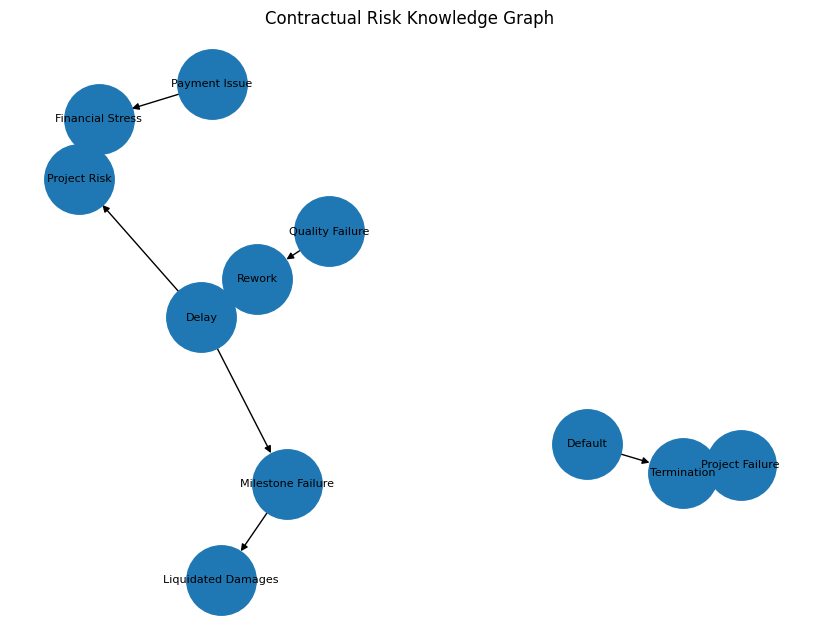

In [199]:
# ==========================
# Figure 3 KG Visualization
# ==========================


import matplotlib.pyplot as plt
import networkx as nx


plt.figure(
    figsize=(8,6)
)


pos=nx.spring_layout(
    G,
    seed=42
)


nx.draw(

    G,

    pos,

    with_labels=True,

    node_size=2500,

    font_size=8

)


plt.title(
"Contractual Risk Knowledge Graph"
)


plt.savefig(
"Fig3_Knowledge_Graph.png",
dpi=300,
bbox_inches="tight"
)


plt.show()

# FIGURE 4 — Model Performance Comparison

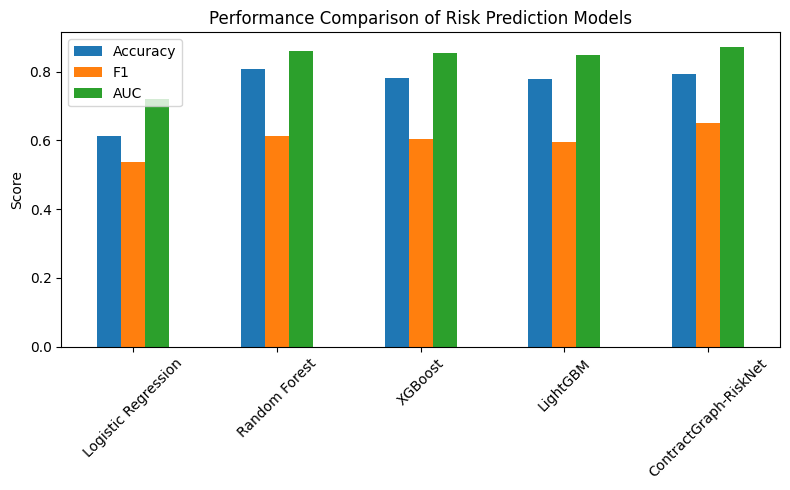

In [200]:
# ==========================
# Figure 4 Model Comparison
# ==========================


results_df[
    ["Accuracy","F1","AUC"]
].plot(

    kind="bar",

    figsize=(8,5)

)


plt.ylabel(
"Score"
)


plt.title(
"Performance Comparison of Risk Prediction Models"
)


plt.xticks(
rotation=45
)


plt.tight_layout()


plt.savefig(
"Fig4_Model_Performance.png",
dpi=300
)


plt.show()

# FIGURE 5 — ROC Curve

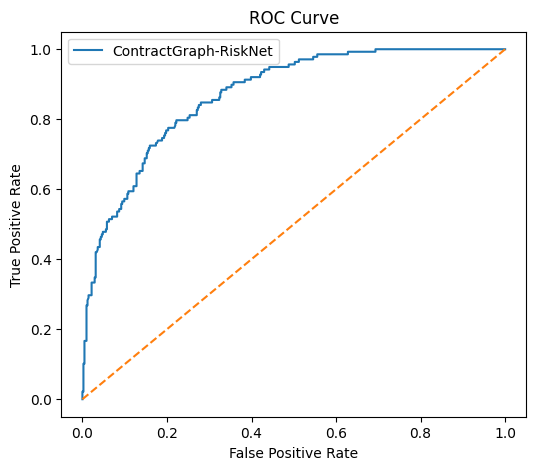

In [201]:
# ===================
# Figure 5 ROC Curve
# ===================


from sklearn.metrics import roc_curve


fpr,tpr,_=roc_curve(

    y_test,

    probs

)


plt.figure(figsize=(6,5))


plt.plot(
    fpr,
    tpr,
    label="ContractGraph-RiskNet"
)


plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)


plt.xlabel(
"False Positive Rate"
)

plt.ylabel(
"True Positive Rate"
)


plt.title(
"ROC Curve"
)


plt.legend()


plt.savefig(
"Fig5_ROC_Curve.png",
dpi=300
)


plt.show()

# FIGURE 6 — Confusion Matrix

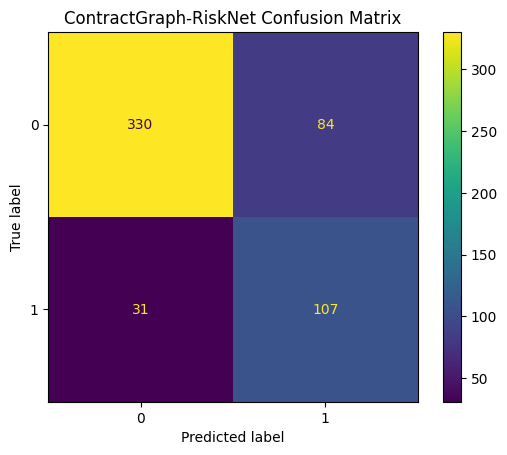

In [202]:
# =====================
# Figure 6 Confusion Matrix
# =====================


from sklearn.metrics import ConfusionMatrixDisplay


ConfusionMatrixDisplay.from_predictions(

    y_test,

    final_preds

)


plt.title(

"ContractGraph-RiskNet Confusion Matrix"

)


plt.savefig(

"Fig6_Confusion_Matrix.png",

dpi=300

)


plt.show()

# FIGURE 7 — Ablation Study

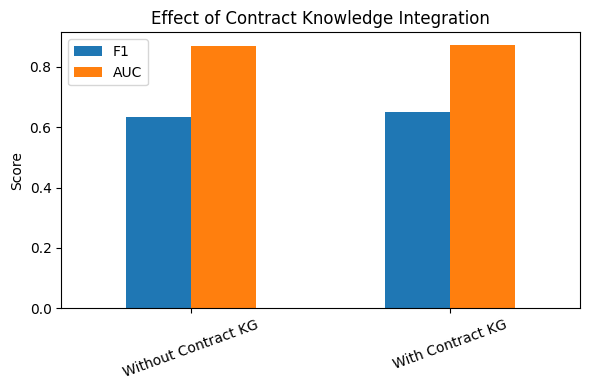

In [203]:
# =====================
# Figure 7 Ablation
# =====================


ablation_df[

["F1","AUC"]

].plot(

kind="bar",

figsize=(6,4)

)


plt.title(

"Effect of Contract Knowledge Integration"

)


plt.ylabel(

"Score"

)


plt.xticks(rotation=20)


plt.tight_layout()


plt.savefig(

"Fig7_Ablation_Study.png",

dpi=300

)


plt.show()

# FIGURE 8 — Feature Importance / Explainability  

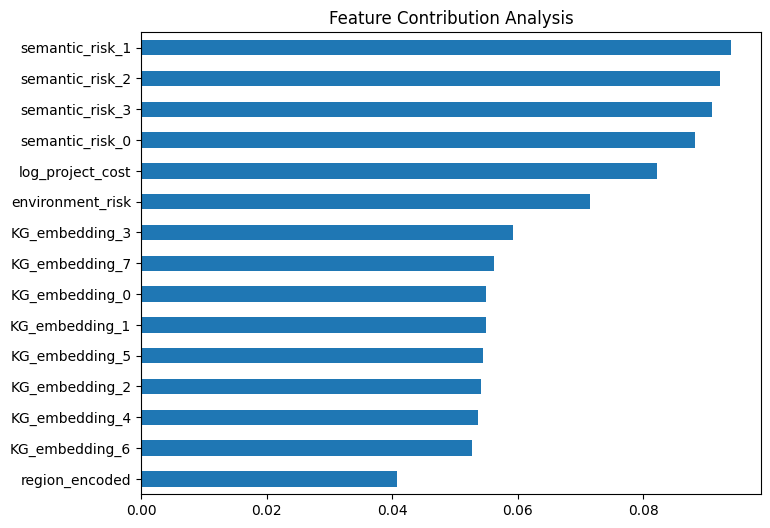

In [204]:
# ======================
# Figure 8 Feature Importance
# ======================


rf = RandomForestClassifier(
    random_state=42
)


rf.fit(
    X_train,
    y_train
)


importance=pd.Series(

rf.feature_importances_,

index=features

)


importance.sort_values().plot(

kind="barh",

figsize=(8,6)

)


plt.title(

"Feature Contribution Analysis"

)


plt.savefig(

"Fig8_Feature_Importance.png",

dpi=300,

bbox_inches="tight"

)


plt.show()

In [205]:
import os

for f in os.listdir("/kaggle/working"):
    print(f)

confusion_matrix.png
feature_importance.png
Fig4_Model_Performance.png
feature_columns.pkl
ablation_results.csv
ContractGraph_RiskNet.pt
Fig7_Ablation_Study.png
contract_risknet_model.pth
ContractGraph_HighwayRiskDataset.csv
HighwayRiskDataset.csv
ContractGraph_RiskNet_FinalDataset.csv
model_results.csv
Fig6_Confusion_Matrix.png
Fig2_Risk_Distribution.png
Fig5_ROC_Curve.png
architecture_summary.txt
risk_scaler.pkl
.virtual_documents
Fig3_Knowledge_Graph.png
road_projects_raw.csv
roc_curve.png
Fig8_Feature_Importance.png
